# 04 — Model Training & Walk-Forward Validation

Run OLS, Ridge, and XGBoost with walk-forward OOS evaluation.
Compare own-only vs full (own + cross-asset) feature sets.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from config import TARGET_ASSETS, SIGNAL_ASSET, OFI_HORIZONS, DEFAULT_FWD_HORIZON
from src.data_loader import load_processed
from src.features import prepare_dataset
from src.evaluation import run_walk_forward, incremental_r2, summarise_results
from src.models import OLSModel

sns.set_style('whitegrid')
%matplotlib inline

## 4.1 Load data

In [2]:
panel = load_processed('panel')
ofi_df = load_processed('ofi_all')
print(f"OFI shape: {ofi_df.shape}, Panel: {panel.shape}")

OFI shape: (98625, 25), Panel: (98625, 25)


## 4.2 OLS baseline — coefficient interpretation

In [3]:
# Fit OLS on the full sample for BANKNIFTY to inspect coefficients
target = 'BANKNIFTY'
close = panel[target]['close']

X_full, y = prepare_dataset(ofi_df, close, target, feature_set='full')

ols = OLSModel()
ols.fit(X_full, y)
coef_table = ols.summary_df()
print(f"\nOLS Coefficients — {target} (full sample, {DEFAULT_FWD_HORIZON}-min fwd return)")
print(coef_table.round(6).to_string())

coef_table.to_csv('../outputs/tables/ols_coefficients_banknifty.csv')


OLS Coefficients — BANKNIFTY (full sample, 5-min fwd return)
                      coef   std_err    t_stat   p_value
const            -0.000015  0.000005 -2.811425  0.004933
BANKNIFTY_ofi_1   0.000003  0.000008  0.337085  0.736053
BANKNIFTY_ofi_5  -0.000018  0.000020 -0.889939  0.373501
BANKNIFTY_ofi_15  0.000070  0.000042  1.677322  0.093483
BANKNIFTY_ofi_30 -0.000011  0.000064 -0.175664  0.860558
BANKNIFTY_ofi_60  0.000090  0.000074  1.219319  0.222726
NIFTY_ofi_1      -0.000002  0.000008 -0.323946  0.745979
NIFTY_ofi_5       0.000043  0.000020  2.142689  0.032141
NIFTY_ofi_15     -0.000244  0.000042 -5.818836  0.000000
NIFTY_ofi_30      0.000271  0.000065  4.202385  0.000026
NIFTY_ofi_60     -0.000118  0.000074 -1.587462  0.112411


## 4.3 Walk-forward evaluation — all models × all targets

In [4]:
model_names = ['ols', 'ridge', 'xgboost']
feature_sets = ['own', 'full']

all_results = []

for target in TARGET_ASSETS:
    close = panel[target]['close']
    for fs in feature_sets:
        X, y = prepare_dataset(ofi_df, close, target, feature_set=fs)
        for mn in model_names:
            print(f"Running: {target} | {fs:4s} | {mn:8s} ... ", end='')
            res = run_walk_forward(X, y, model_name=mn)
            res['target'] = target
            res['feature_set'] = fs
            res['model'] = mn
            all_results.append(res)
            summary = summarise_results(res)
            print(f"folds={int(summary['n_folds'])}  IC={summary['mean_ic']:.4f}  R²={summary['mean_r2']:.4f}")

results_df = pd.concat(all_results, ignore_index=True)
results_df.to_csv('../outputs/tables/walk_forward_results.csv', index=False)
print(f"\nSaved {len(results_df)} fold results.")

Running: BANKNIFTY | own  | ols      ... folds=7  IC=0.0137  R²=-0.0001
Running: BANKNIFTY | own  | ridge    ... folds=7  IC=0.0127  R²=-0.0001
Running: BANKNIFTY | own  | xgboost  ... folds=7  IC=0.0131  R²=-0.0021
Running: BANKNIFTY | full | ols      ... folds=7  IC=0.0147  R²=-0.0002
Running: BANKNIFTY | full | ridge    ... folds=7  IC=0.0143  R²=-0.0002
Running: BANKNIFTY | full | xgboost  ... folds=7  IC=-0.0002  R²=-0.0046
Running: HDFCBANK | own  | ols      ... folds=7  IC=0.0020  R²=-0.0011
Running: HDFCBANK | own  | ridge    ... folds=7  IC=0.0018  R²=-0.0010
Running: HDFCBANK | own  | xgboost  ... folds=7  IC=0.0120  R²=-0.0029
Running: HDFCBANK | full | ols      ... folds=7  IC=0.0033  R²=-0.0017
Running: HDFCBANK | full | ridge    ... folds=7  IC=0.0038  R²=-0.0016
Running: HDFCBANK | full | xgboost  ... folds=7  IC=0.0093  R²=-0.0039
Running: RELIANCE | own  | ols      ... folds=7  IC=-0.0112  R²=-0.0017
Running: RELIANCE | own  | ridge    ... folds=7  IC=-0.0114  R²=-0.00

## 4.4 Summary table

In [5]:
summary_rows = []

for (target, fs, mn), grp in results_df.groupby(['target', 'feature_set', 'model']):
    s = summarise_results(grp)
    s['target'] = target
    s['feature_set'] = fs
    s['model'] = mn
    summary_rows.append(s)

summary_table = pd.DataFrame(summary_rows)
summary_table = summary_table[['target', 'model', 'feature_set', 'n_folds',
                                'mean_ic', 'ic_tstat', 'ic_pvalue', 'mean_r2']]
summary_table = summary_table.sort_values(['target', 'model', 'feature_set'])

print(summary_table.round(4).to_string(index=False))
summary_table.to_csv('../outputs/tables/summary_table.csv', index=False)

   target   model feature_set  n_folds  mean_ic  ic_tstat  ic_pvalue  mean_r2
BANKNIFTY     ols        full      7.0   0.0147    1.4860     0.1878  -0.0002
BANKNIFTY     ols         own      7.0   0.0137    0.7377     0.4885  -0.0001
BANKNIFTY   ridge        full      7.0   0.0143    1.4788     0.1897  -0.0002
BANKNIFTY   ridge         own      7.0   0.0127    0.6964     0.5122  -0.0001
BANKNIFTY xgboost        full      7.0  -0.0002   -0.0265     0.9797  -0.0046
BANKNIFTY xgboost         own      7.0   0.0131    0.5635     0.5935  -0.0021
 HDFCBANK     ols        full      7.0   0.0033    0.1543     0.8824  -0.0017
 HDFCBANK     ols         own      7.0   0.0020    0.1015     0.9225  -0.0011
 HDFCBANK   ridge        full      7.0   0.0038    0.1795     0.8634  -0.0016
 HDFCBANK   ridge         own      7.0   0.0018    0.0896     0.9315  -0.0010
 HDFCBANK xgboost        full      7.0   0.0093    0.5000     0.6349  -0.0039
 HDFCBANK xgboost         own      7.0   0.0120    0.9952     0.

## 4.5 IC over time (stability check)

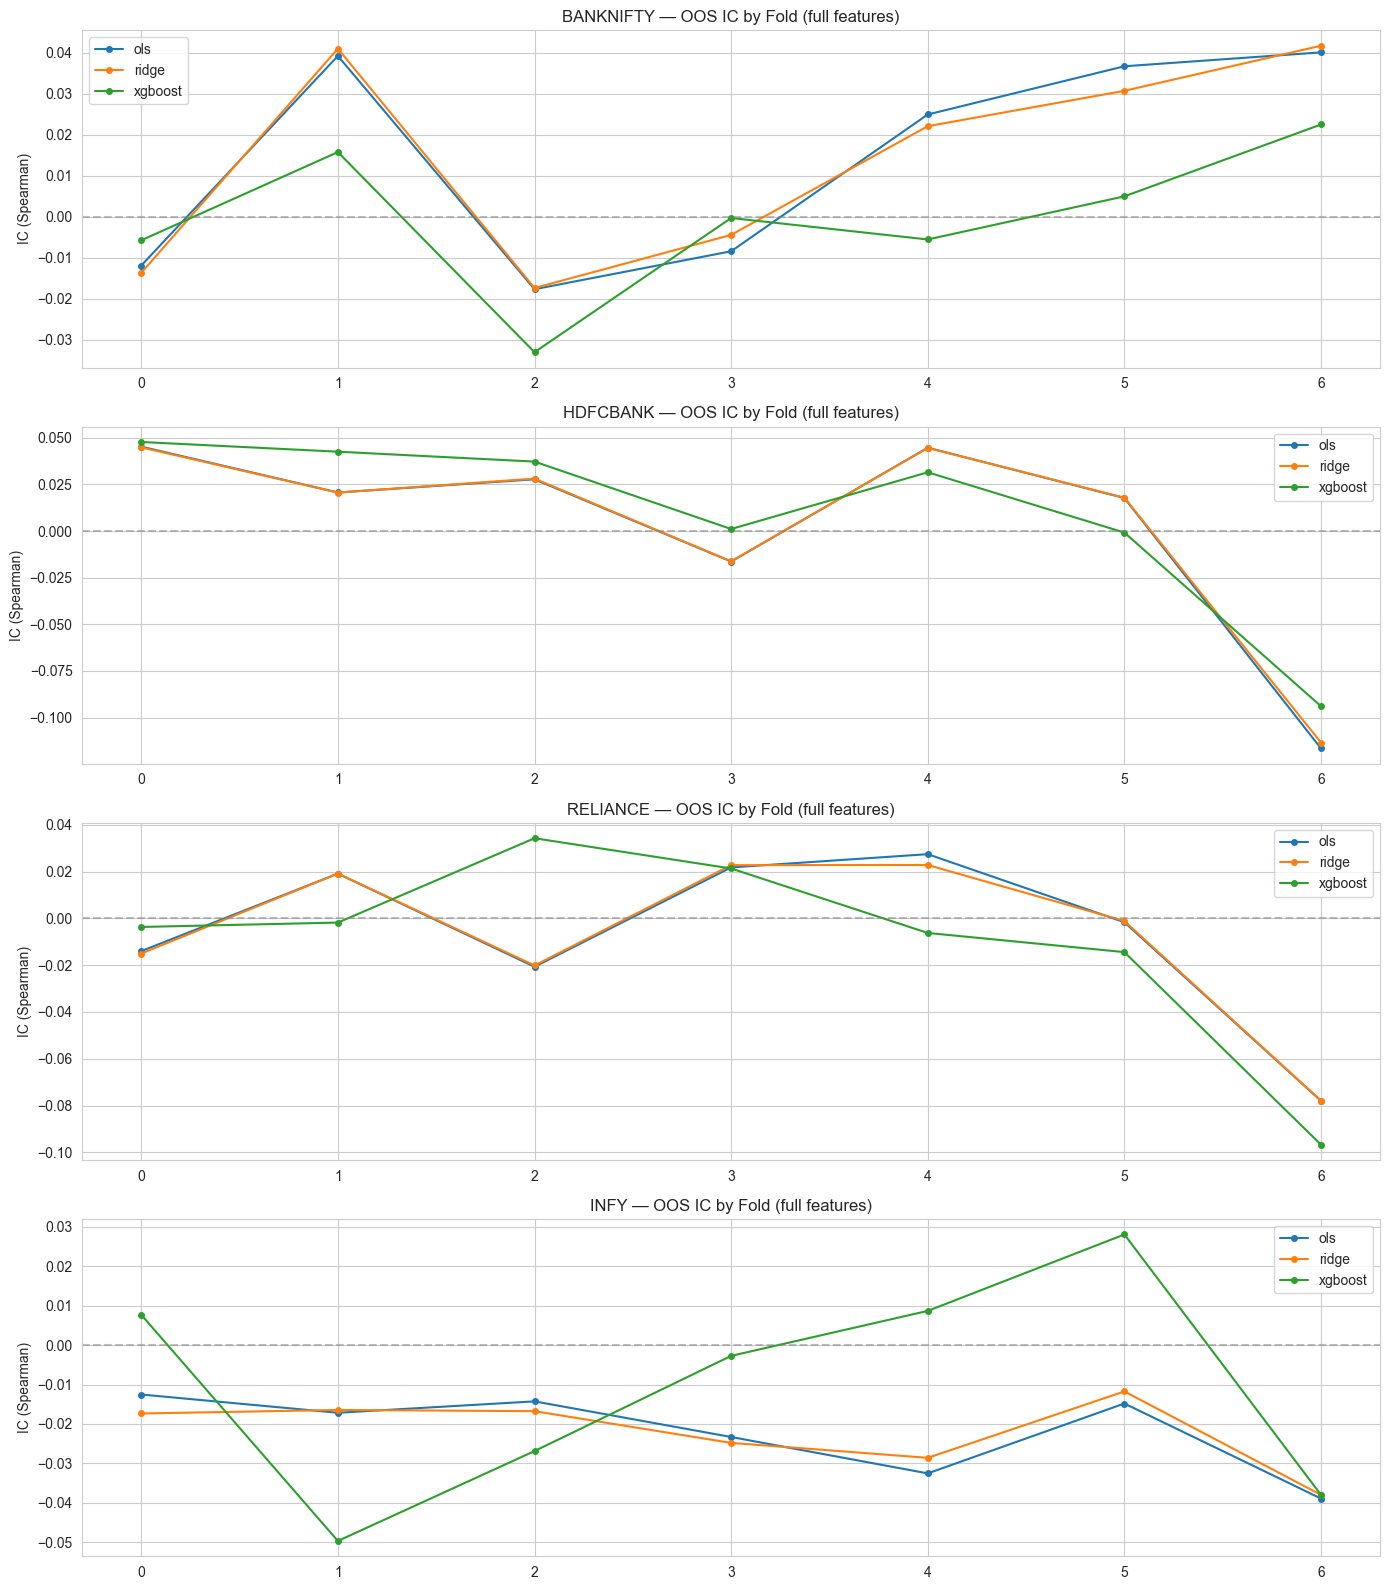

In [6]:
fig, axes = plt.subplots(len(TARGET_ASSETS), 1, figsize=(14, 4 * len(TARGET_ASSETS)), sharex=False)

for ax, target in zip(axes, TARGET_ASSETS):
    for mn in model_names:
        mask = (results_df['target'] == target) & (results_df['model'] == mn) & (results_df['feature_set'] == 'full')
        sub = results_df[mask]
        ax.plot(sub['fold'], sub['ic'], marker='o', label=mn, markersize=4)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{target} — OOS IC by Fold (full features)')
    ax.set_ylabel('IC (Spearman)')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/ic_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.6 Ridge coefficients (best model)

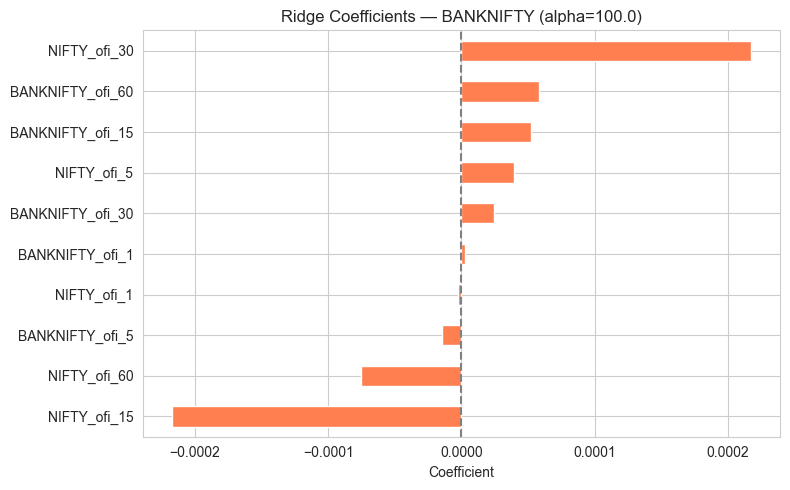

In [7]:
from src.models import RidgeModel

target = 'BANKNIFTY'
close = panel[target]['close']
X_full, y = prepare_dataset(ofi_df, close, target, feature_set='full')

ridge = RidgeModel()
ridge.fit(X_full, y)

fig, ax = plt.subplots(figsize=(8, 5))
coefs = ridge.coefs.sort_values()
colors = ['coral' if SIGNAL_ASSET in c else 'steelblue' for c in coefs.index]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title(f'Ridge Coefficients — {target} (alpha={ridge.best_alpha})')
ax.axvline(0, color='gray', linestyle='--')
ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('../outputs/figures/ridge_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()